In [1]:
import numpy as np
import jax
import jax.numpy as jnp
import equinox as eqx
import diffrax
from jaxtyping import Float

import dismech_jax as djx

from util_multiset_copy import *
from animate import animate

jax.config.update("jax_enable_x64", True)


In [2]:
class MLP(eqx.Module):
    layer1: eqx.nn.Linear
    layer2: eqx.nn.Linear

    def __init__(self, in_features: int, hidden_size: int, key: jax.Array):
        key1, key2 = jax.random.split(key)
        self.layer1 = eqx.nn.Linear(in_features, hidden_size, key=key1)
        self.layer2 = eqx.nn.Linear(hidden_size, 1, key=key2)

        self.layer1 = eqx.tree_at(
            lambda l: l.weight, self.layer1, self.layer1.weight * 1e-2
        )
        self.layer2 = eqx.tree_at(
            lambda l: l.weight, self.layer2, self.layer2.weight * 1e-2
        )

    def __call__(self, x: jax.Array) -> jax.Array:
        x = jax.nn.softplus(self.layer1(x))
        x = self.layer2(x)
        return jax.nn.softplus(x[0])


class Example(TripletModel):
    K: jax.Array  # = eqx.field(static=True)
    mlp: MLP

    def __init__(self, der_K: jax.Array, key: jax.Array):
        self.K = der_K
        self.mlp = MLP(5, 10, key)

    def __call__(self, del_strain: Float[jax.Array, "5"]) -> Float[jax.Array, ""]:
        stretching_energy = 0.5 * (self.K[0] * del_strain[0]**2 + self.K[0] * del_strain[1]**2)
        bending_energy = 0.5 * (self.K[1] * del_strain[3]**2)
        return stretching_energy + bending_energy



In [3]:
# train_datafile = "experiment_data/train_from_experiment.npz"
# valid_datafile = "experiment_data/train_from_experiment.npz"

train_datafile = "experiment_data/train.npz"
valid_datafile = "experiment_data/valid.npz"

init_K=jnp.array([0.1, 0.05])
validate_model(Example, der_K=init_K)

final_model, init_K, train_history, valid_history = train_model(Example, key=jax.random.PRNGKey(42), train_file=train_datafile, valid_file=valid_datafile, n_epochs=500, lr=1e-2, init_K=init_K )

print( "initial K: ", init_K)
print( "learned K: ", final_model.K)

Initial training loss: 1.28929e-04
K: [0.1  0.05]
grad K: [0.00018907 0.00207778]
loss finite? True
grad finite? True
Step 0    | LR: 1.000e-02  | Train: 1.28929e-04  | Valid: 1.05906e-04  | K: [0.09000053 0.04000005]
Step 10   | LR: 9.991e-03  | Train: 1.46821e-05  | Valid: 1.11674e-05  | K: [0.0223999  0.01996929]
Step 20   | LR: 9.965e-03  | Train: 7.95396e-06  | Valid: 7.42708e-06  | K: [0.04284135 0.01700027]
Step 30   | LR: 9.921e-03  | Train: 4.28842e-06  | Valid: 3.44633e-06  | K: [0.02433668 0.01702171]
Step 40   | LR: 9.859e-03  | Train: 2.89504e-06  | Valid: 2.75370e-06  | K: [0.03287205 0.01575224]
Step 50   | LR: 9.781e-03  | Train: 2.29476e-06  | Valid: 2.41644e-06  | K: [0.02895853 0.01552168]
Step 60   | LR: 9.685e-03  | Train: 2.33223e-06  | Valid: 2.36122e-06  | K: [0.02807438 0.01566543]
Step 70   | LR: 9.573e-03  | Train: 2.28773e-06  | Valid: 2.33931e-06  | K: [0.02998771 0.01587519]
Step 80   | LR: 9.446e-03  | Train: 2.27700e-06  | Valid: 2.29668e-06  | K: [0.029

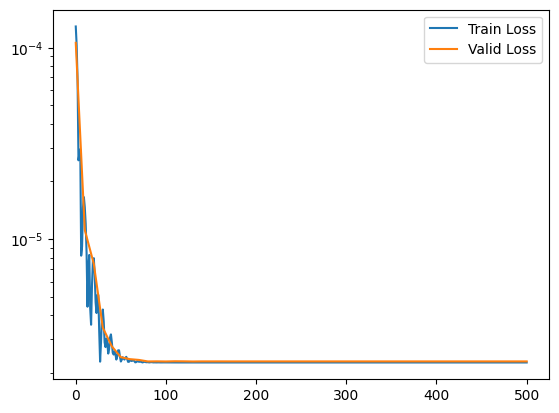

In [4]:
import matplotlib.pyplot as plt
train_np = np.asarray(train_history, dtype=float).reshape(-1)
valid_np = np.asarray(valid_history, dtype=float).reshape(-1)

idx_valid = np.where(valid_np != -1)[0]

plt.plot(np.arange(train_np.size), train_np, label="Train Loss")
plt.plot(idx_valid, valid_np[idx_valid], label="Valid Loss")
plt.yscale("log")
plt.legend()
plt.show()

In [5]:
from util_multiset_copy import TestCase

train = TestCase.from_npz(train_datafile)
valid = TestCase.from_npz(valid_datafile)


print("train.qs finite:", jnp.all(jnp.isfinite(train.qs)))
print("train.xb finite:", jnp.all(jnp.isfinite(train.xb)))
print("train.lambdas finite:", True if train.lambdas is None else jnp.all(jnp.isfinite(train.lambdas)))

print("valid.qs finite:", jnp.all(jnp.isfinite(valid.qs)))
print("valid.xb finite:", jnp.all(jnp.isfinite(valid.xb)))
print("valid.lambdas finite:", True if valid.lambdas is None else jnp.all(jnp.isfinite(valid.lambdas)))


train.qs finite: True
train.xb finite: True
train.lambdas finite: True
valid.qs finite: True
valid.xb finite: True
valid.lambdas finite: True


In [6]:
# base, aux, der = get_base_rod()
# train = TestCase.from_npz(train_datafile)

# model = Example(der_K=jnp.array([0.1, 0.05]), key=jax.random.PRNGKey(42))
# debug_dataset_loss(model, base, aux, train)

In [7]:
def make_bc_from_testcase(dataset, i=None):
    lambdas = dataset.lambdas if dataset.lambdas is not None else jnp.linspace(0.0, 1.0, dataset.qs.shape[1])

    if i is None:
        idx_b = dataset.idx_b
        xb = dataset.xb
    else:
        idx_b = dataset.idx_b if dataset.idx_b.ndim == 1 else dataset.idx_b[i]
        xb = dataset.xb[i]

    print("xb.shape", xb.shape)
    return djx.BatchedDirectBC(
        idx_b=idx_b,
        xb=xb,
        lambdas=lambdas,
    )

In [8]:
print("valid.xb.shape", valid.xb.shape)
lambdas = valid.lambdas if valid.lambdas is not None else jnp.linspace(0.0, 1.0, valid.qs.shape[1])
base, aux, _ = get_base_rod()
bc = make_bc_from_testcase(valid)
rod = base.with_bc(bc)
pred = rod.solve(final_model, lambdas, aux, max_dlambda=5e-3, iters=5, ls_steps=10)
print("pred.shape", pred.shape)
print("valid.qs.shape", valid.qs.shape)
print("train.qs.shape", train.qs.shape)
# animate(pred)

valid.xb.shape (8, 40, 8)
xb.shape (8, 40, 8)
pred.shape (8, 40, 11)
valid.qs.shape (8, 40, 11)
train.qs.shape (8, 40, 11)


In [9]:
# animate(valid.qs)

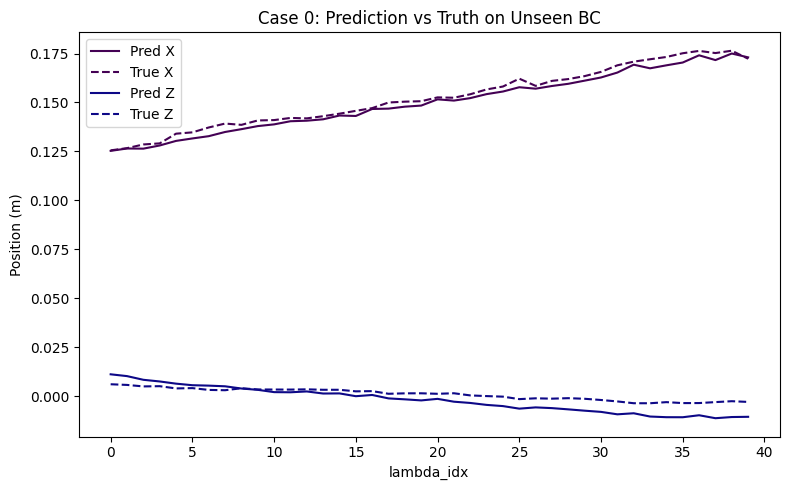

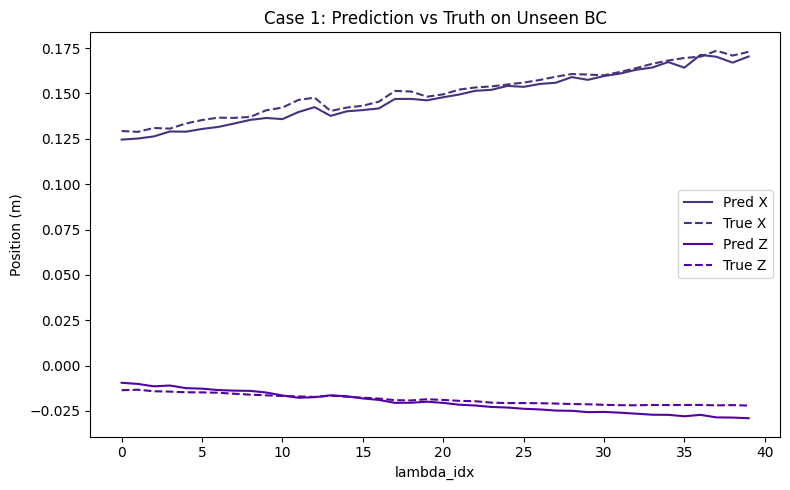

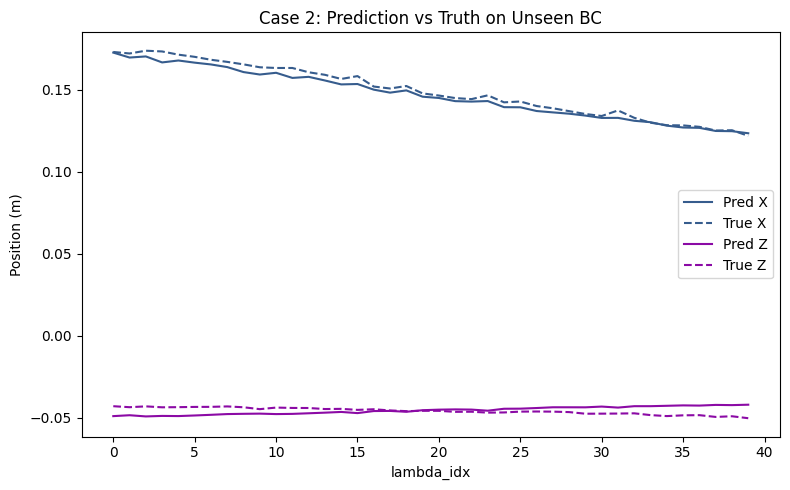

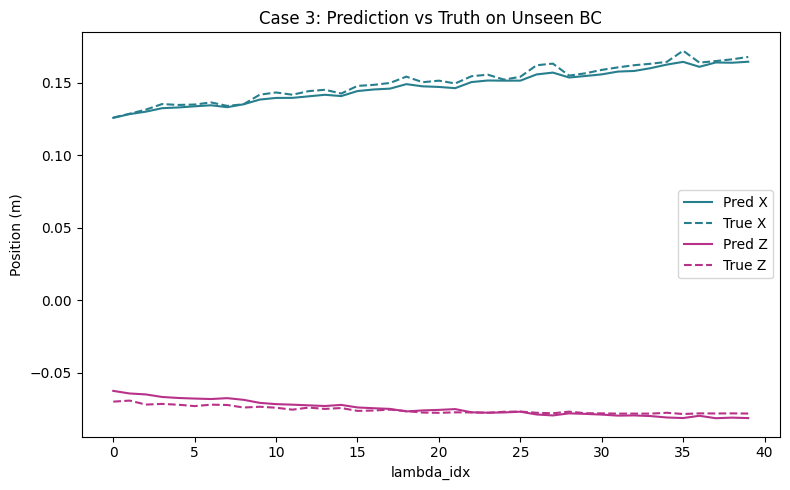

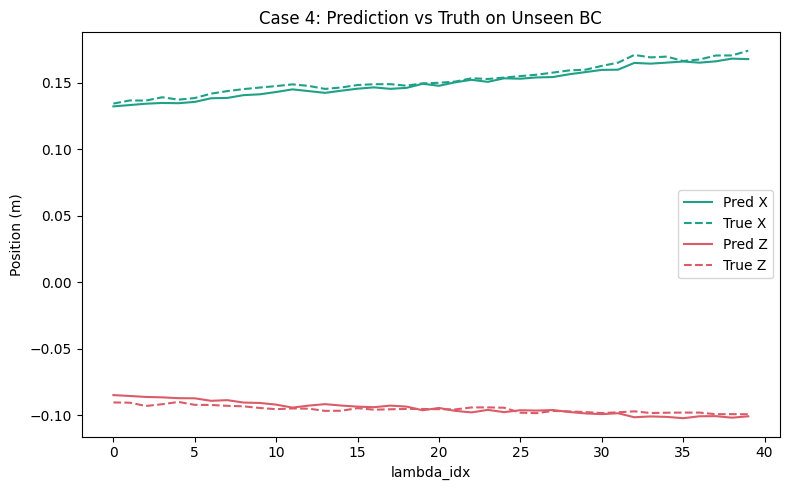

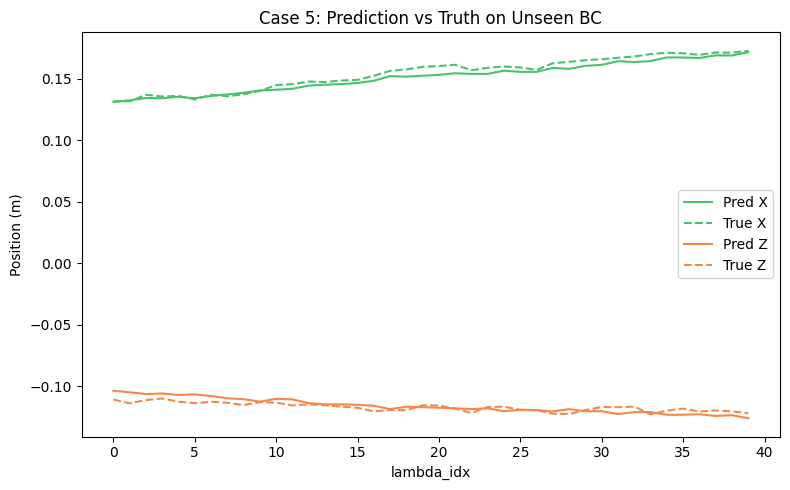

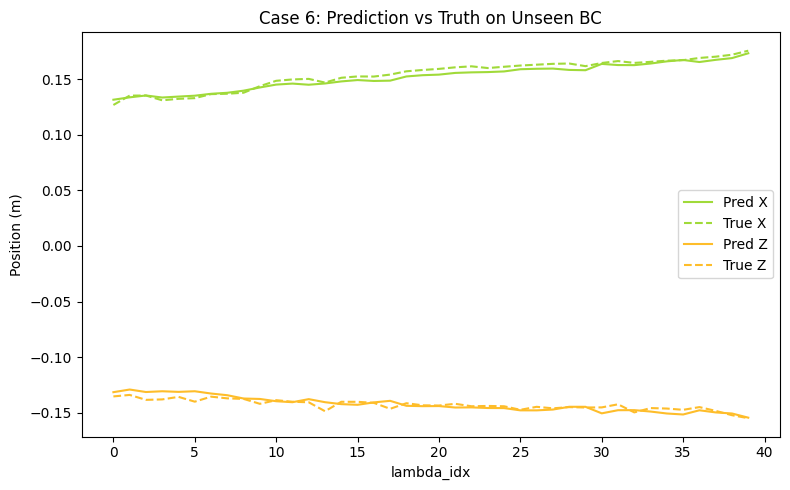

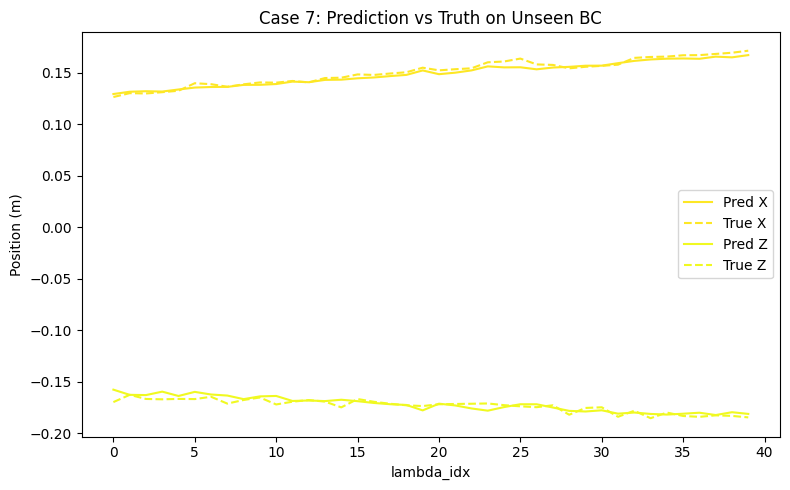

In [10]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import jax.numpy as jnp

n_cases = pred.shape[0]

# one colormap per coordinate
colors_x = cm.viridis(jnp.linspace(0, 1, n_cases))
colors_z = cm.plasma(jnp.linspace(0, 1, n_cases))

for i in range(n_cases):
    cx = colors_x[i]
    cz = colors_z[i]

    fig, ax = plt.subplots(figsize=(8, 5))

    # X coordinate
    ax.plot(pred[i, :, 4], color=cx, linestyle='-', label='Pred X')
    ax.plot(valid.qs[i, :, 4], color=cx, linestyle='--', label='True X')

    # Z coordinate
    ax.plot(pred[i, :, 6], color=cz, linestyle='-', label='Pred Z')
    ax.plot(valid.qs[i, :, 6], color=cz, linestyle='--', label='True Z')

    ax.set_title(f"Case {i}: Prediction vs Truth on Unseen BC")
    ax.set_xlabel("lambda_idx")
    ax.set_ylabel("Position (m)")
    ax.legend()
    fig.tight_layout()
    plt.show()

In [11]:
print("Training BC:")
print("init: ", train.qs[0, 8:11])
print("final: ", train.qs[-1, 8:11])

print("Validation BC:")
print("init: ", valid.qs[0, 8:11])
print("final: ", valid.qs[-1, 8:11])

Training BC:
init:  [[0.         0.         0.         0.         0.16428576 0.
  0.01229775 0.         0.32682654 0.         0.13977266]
 [0.         0.         0.         0.         0.16303527 0.
  0.01308039 0.         0.32530566 0.         0.13923934]
 [0.         0.         0.         0.         0.15640293 0.
  0.01301728 0.         0.3172655  0.         0.13868152]]
final:  [[ 0.          0.          0.          0.          0.16309561  0.
  -0.15344538  0.          0.32634914  0.         -0.18034504]
 [ 0.          0.          0.          0.          0.16026018  0.
  -0.15141121  0.          0.3255293   0.         -0.18462522]
 [ 0.          0.          0.          0.          0.15990571  0.
  -0.15042114  0.          0.31977792  0.         -0.18008941]]
Validation BC:
init:  [[0.         0.         0.         0.         0.13856692 0.
  0.0039613  0.         0.27440777 0.         0.11285062]
 [0.         0.         0.         0.         0.14081248 0.
  0.00335446 0.         0.277

In [12]:
print("initial position of the middle node in the training data: ", train.qs[0, 4:7])
print("final position of the middle node in the training data: ", train.qs[-1, 4:7])

initial position of the middle node in the training data:  [[0.         0.         0.         0.         0.17430091 0.
  0.01355381 0.         0.33866367 0.         0.13729598]
 [0.         0.         0.         0.         0.16942554 0.
  0.01341526 0.         0.33447406 0.         0.1386963 ]
 [0.         0.         0.         0.         0.1670495  0.
  0.01400291 0.         0.32791504 0.         0.13421736]]
final position of the middle node in the training data:  [[ 0.          0.          0.          0.          0.16568868  0.
  -0.15070113  0.          0.33929003  0.         -0.18367317]
 [ 0.          0.          0.          0.          0.164255    0.
  -0.15390902  0.          0.33209236  0.         -0.17952158]
 [ 0.          0.          0.          0.          0.1639525   0.
  -0.15416049  0.          0.32664102  0.         -0.1765561 ]]


In [13]:
print("initial position of the middle node in the validation data: ", valid.qs[0, 4:7])
print("final position of the middle node in the validation data: ", valid.qs[-1, 4:7])

initial position of the middle node in the validation data:  [[0.         0.         0.         0.         0.13405191 0.
  0.00387515 0.         0.26362414 0.         0.11435032]
 [0.         0.         0.         0.         0.13473146 0.
  0.00403559 0.         0.26587429 0.         0.11339072]
 [0.         0.         0.         0.         0.13722261 0.
  0.00311249 0.         0.26794605 0.         0.11373071]]
final position of the middle node in the validation data:  [[ 0.          0.          0.          0.          0.13252028  0.
  -0.16677108  0.          0.26937761  0.         -0.20982013]
 [ 0.          0.          0.          0.          0.13982214  0.
  -0.16692505  0.          0.27305123  0.         -0.20214286]
 [ 0.          0.          0.          0.          0.13888024  0.
  -0.16469997  0.          0.27458906  0.         -0.20636286]]


In [14]:
print("initial position of the middle node in the prediction: ", pred[0, 4:7])
print("final position of the middle node in the prediction: ", pred[-1, 4:7])

initial position of the middle node in the prediction:  [[0.         0.         0.         0.         0.13036387 0.
  0.00631469 0.         0.26362414 0.         0.11435032]
 [0.         0.         0.         0.         0.13161877 0.
  0.00551819 0.         0.26587429 0.         0.11339072]
 [0.         0.         0.         0.         0.13277796 0.
  0.00530635 0.         0.26794605 0.         0.11373071]]
final position of the middle node in the prediction:  [[ 0.          0.          0.          0.          0.13373203  0.
  -0.16391977  0.          0.26937761  0.         -0.20982013]
 [ 0.          0.          0.          0.          0.13560377  0.
  -0.15992874  0.          0.27305123  0.         -0.20214286]
 [ 0.          0.          0.          0.          0.13615203  0.
  -0.16248189  0.          0.27458906  0.         -0.20636286]]
